In [ ]:
# Install any missing packages
!pip install torch torchvision matplotlib -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if device.type == 'cuda':
    print(f"✅ GPU Name: {torch.cuda.get_device_name(0)}")

✅ Using device: cpu


In [ ]:
# Data augmentation and transforms
print("🔄 Setting up data transforms...")

# Training transforms with data augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomCrop(32, padding=4),  # Random crop
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Test transforms (no augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

print("✅ Data transforms ready")

🔄 Setting up data transforms...
✅ Data transforms ready


In [ ]:
# Load CIFAR-10 dataset
print("📥 Downloading CIFAR-10 dataset...")

# Training set
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)

# Test set
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"✅ Training samples: {len(trainset)}")
print(f"✅ Test samples: {len(testset)}")
print(f"✅ Classes: {classes}")

📥 Downloading CIFAR-10 dataset...


100%|██████████| 170M/170M [44:16<00:00, 64.2kB/s]


✅ Training samples: 50000
✅ Test samples: 10000
✅ Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


🖼️ Displaying sample images...


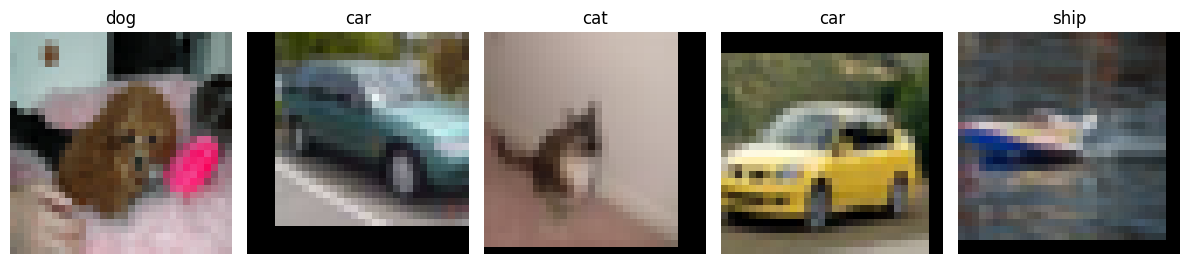

✅ Sample images saved as 'sample_images.png'


In [ ]:
# Display sample images
print("🖼️ Displaying sample images...")

# Get batch of training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i in range(5):
    # Denormalize
    img = images[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()
print("✅ Sample images saved as 'sample_images.png'")

In [ ]:
# Build model with Transfer Learning
print("🏗️ Building ResNet18 model...")

# Load pretrained ResNet18
model = resnet18(pretrained=True)

# Modify for CIFAR-10 (32x32 images need different first layer)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

# Replace final layer for 10 classes
model.fc = nn.Linear(512, 10)

# Move to GPU if available
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✅ Model ready")
print(f"✅ Total parameters: {sum(p.numel() for p in model.parameters()):,}")

🏗️ Building ResNet18 model...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


✅ Model ready
✅ Total parameters: 11,173,962


In [6]:
# Training loop
print("\n🚀 Starting training...")
print("-" * 50)

epochs = 10  # 10 epochs for good accuracy
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    # Training phase
    model.train()
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    train_losses.append(avg_loss)

    # Validation phase
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {accuracy:.2f}%")

print("-" * 50)
print("✅ Training complete!")


🚀 Starting training...
--------------------------------------------------
Epoch 1/10 - Loss: 1.1612 - Accuracy: 71.54%
Epoch 2/10 - Loss: 0.7526 - Accuracy: 74.78%
Epoch 3/10 - Loss: 0.6173 - Accuracy: 78.17%
Epoch 4/10 - Loss: 0.5524 - Accuracy: 82.85%
Epoch 5/10 - Loss: 0.5127 - Accuracy: 81.51%
Epoch 6/10 - Loss: 0.4497 - Accuracy: 83.49%
Epoch 7/10 - Loss: 0.4342 - Accuracy: 84.23%
Epoch 8/10 - Loss: 0.3962 - Accuracy: 82.53%
Epoch 9/10 - Loss: 0.3660 - Accuracy: 85.78%
Epoch 10/10 - Loss: 0.3509 - Accuracy: 84.84%
--------------------------------------------------
✅ Training complete!



📈 Plotting training curves...


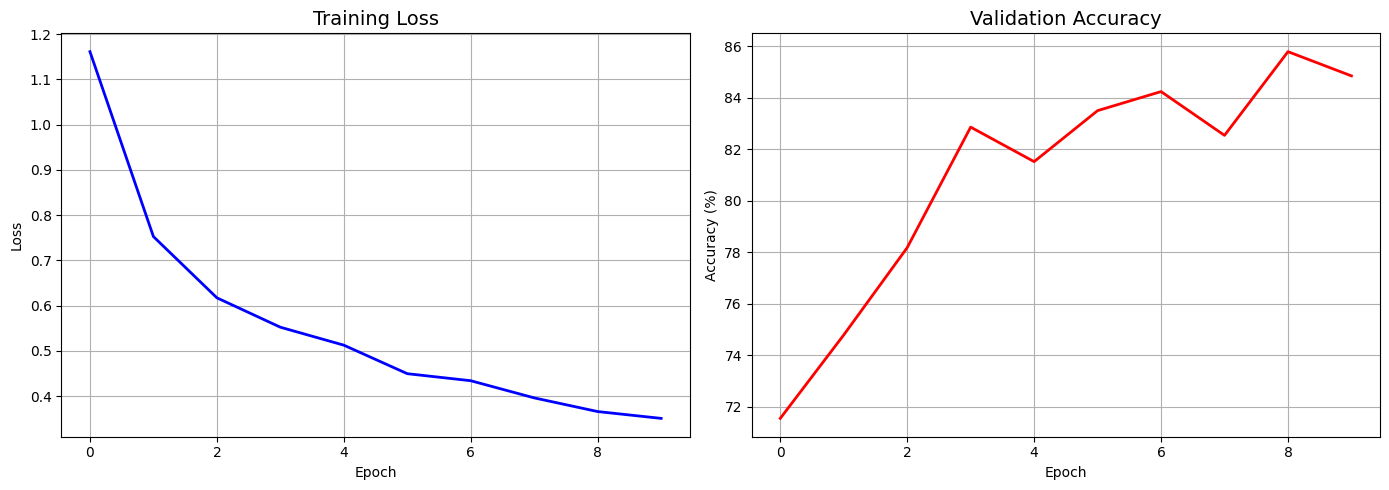

✅ Training curves saved as 'training_curves.png'


In [7]:
# Plot training curves
print("\n📈 Plotting training curves...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, 'b-', linewidth=2)
ax1.set_title('Training Loss', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Accuracy plot
ax2.plot(val_accuracies, 'r-', linewidth=2)
ax2.set_title('Validation Accuracy', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()
print("✅ Training curves saved as 'training_curves.png'")


📊 Final Evaluation on Test Set...
--------------------------------------------------
✅ Final Test Accuracy: 84.84%

📋 Classification Report:
              precision    recall  f1-score   support

       plane       0.84      0.90      0.87      1000
         car       0.97      0.87      0.92      1000
        bird       0.76      0.85      0.81      1000
         cat       0.69      0.75      0.72      1000
        deer       0.90      0.80      0.85      1000
         dog       0.82      0.72      0.77      1000
        frog       0.77      0.94      0.85      1000
       horse       0.97      0.84      0.90      1000
        ship       0.94      0.89      0.92      1000
       truck       0.89      0.92      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



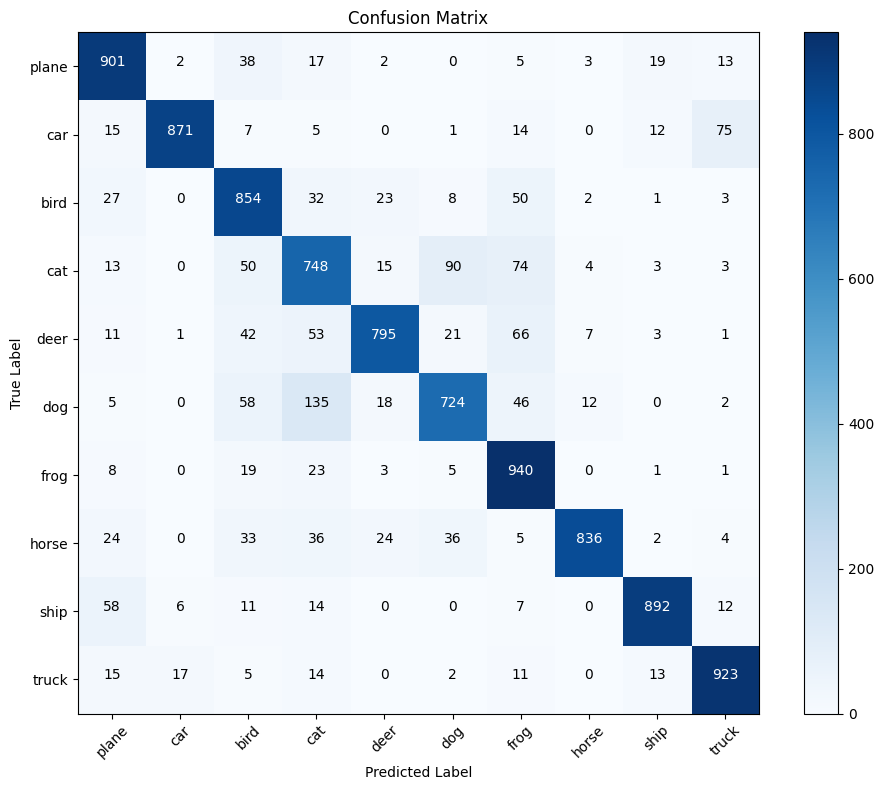

✅ Confusion matrix saved as 'confusion_matrix.png'


In [8]:
# Final evaluation
print("\n📊 Final Evaluation on Test Set...")
print("-" * 50)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate accuracy
from sklearn.metrics import accuracy_score
final_accuracy = accuracy_score(all_labels, all_preds)
print(f"✅ Final Test Accuracy: {final_accuracy*100:.2f}%")

# Classification report
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add numbers to confusion matrix
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("✅ Confusion matrix saved as 'confusion_matrix.png'")

In [9]:
# Save the model
print("\n💾 Saving model...")

# Save model state dictionary
torch.save(model.state_dict(), 'cifar10_model.pth')
print("✅ Model saved as 'cifar10_model.pth'")

# Save full model for easy loading
torch.save(model, 'cifar10_model_full.pth')
print("✅ Full model saved as 'cifar10_model_full.pth'")


💾 Saving model...
✅ Model saved as 'cifar10_model.pth'
✅ Full model saved as 'cifar10_model_full.pth'



🔮 Testing inference on sample images...


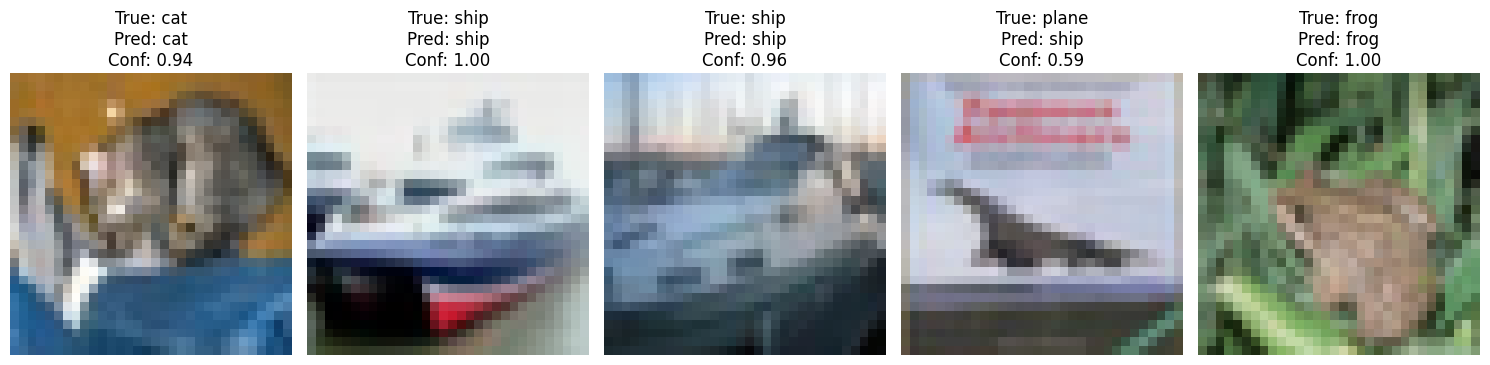

✅ Inference examples saved as 'inference_examples.png'


In [10]:
# Inference function and example
print("\n🔮 Testing inference on sample images...")

def inference(image_tensor):
    """Run inference on a single image tensor"""
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        output = model(image_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        predicted_class = torch.argmax(probabilities).item()
        confidence = probabilities[predicted_class].item()
        return classes[predicted_class], confidence

# Test on 5 random test images
dataiter = iter(testloader)
images, labels = next(dataiter)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    img = images[i].cpu()
    true_label = classes[labels[i]]

    # Run inference
    predicted, confidence = inference(img.unsqueeze(0))

    # Denormalize for display
    img_display = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    axes[i].imshow(img_display)
    axes[i].set_title(f'True: {true_label}\nPred: {predicted}\nConf: {confidence:.2f}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('inference_examples.png')
plt.show()
print("✅ Inference examples saved as 'inference_examples.png'")

In [11]:
# Show all generated files
print("\n📁 GENERATED FILES:")
print("-" * 50)

import os
files = [
    'sample_images.png',
    'training_curves.png',
    'confusion_matrix.png',
    'inference_examples.png',
    'cifar10_model.pth',
    'cifar10_model_full.pth'
]

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        if size > 1024:
            print(f"✅ {file} ({size/1024:.2f} MB)")
        else:
            print(f"✅ {file} ({size:.1f} KB)")
    else:
        print(f"❌ {file} not found")

print("\n🎉 Task 2 Complete!")
print("\n📝 Instructions for running inference on new images:")
print("1. Load the model using: model = torch.load('cifar10_model_full.pth')")
print("2. Preprocess image using transform_test")
print("3. Call inference() function with your image tensor")


📁 GENERATED FILES:
--------------------------------------------------
✅ sample_images.png (23.6 KB)
✅ training_curves.png (46.6 KB)
✅ confusion_matrix.png (63.2 KB)
✅ inference_examples.png (35.7 KB)
✅ cifar10_model.pth (42.70 MB)
✅ cifar10_model_full.pth (42.71 MB)

🎉 Task 2 Complete!

📝 Instructions for running inference on new images:
1. Load the model using: model = torch.load('cifar10_model_full.pth')
2. Preprocess image using transform_test
3. Call inference() function with your image tensor
